# Macao tourism recovery and employment conditions

This notebook reproduces the Member 2 preliminary analysis for the research question: Is there a relationship between visitor arrivals and unemployment rates in Macao during the post-pandemic recovery period? Data are quarterly DSEC observations for 2023 to 2025.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'Quarter': ['2023 Q1','2023 Q2','2023 Q3','2023 Q4','2024 Q1','2024 Q2','2024 Q3','2024 Q4','2025 Q1','2025 Q2','2025 Q3','2025 Q4'],
    'Visitor_arrivals_thousand': [4948.4,6697.7,8281.8,8284.8,8875.8,7844.2,9200.9,9007.7,9862.7,9355.9,10452.5,10398.3],
    'General_unemployment_rate_percent': [3.1,2.8,2.4,2.3,2.1,1.7,1.7,1.7,1.9,1.9,1.8,1.8],
    'Total_employment_thousand': [359.3,361.4,369.3,371.1,371.1,376.4,379.3,378.3,371.8,372.7,375.3,379.3]
})
data

,Quarter,Visitor_arrivals_thousand,General_unemployment_rate_percent,Total_employment_thousand
0,2023 Q1,4948.4,3.1,359.3
1,2023 Q2,6697.7,2.8,361.4
2,2023 Q3,8281.8,2.4,369.3
3,2023 Q4,8284.8,2.3,371.1
4,2024 Q1,8875.8,2.1,371.1
5,2024 Q2,7844.2,1.7,376.4
6,2024 Q3,9200.9,1.7,379.3
7,2024 Q4,9007.7,1.7,378.3
8,2025 Q1,9862.7,1.9,371.8
9,2025 Q2,9355.9,1.9,372.7


## Correlation and simple linear fit

Pearson correlation describes the quarterly association. The fitted line is descriptive and does not establish causation.

In [2]:
x = data['Visitor_arrivals_thousand'].to_numpy()
y = data['General_unemployment_rate_percent'].to_numpy()
r = np.corrcoef(x, y)[0, 1]
slope, intercept = np.polyfit(x, y, 1)
print(f'Pearson r: {r:.3f}')
print(f'R-squared: {r**2:.3f}')
print(f'Slope: {slope * 1000:.3f} percentage points per 1 million visitors')

Pearson r: -0.842
R-squared: 0.709
Slope: -0.248 percentage points per 1 million visitors


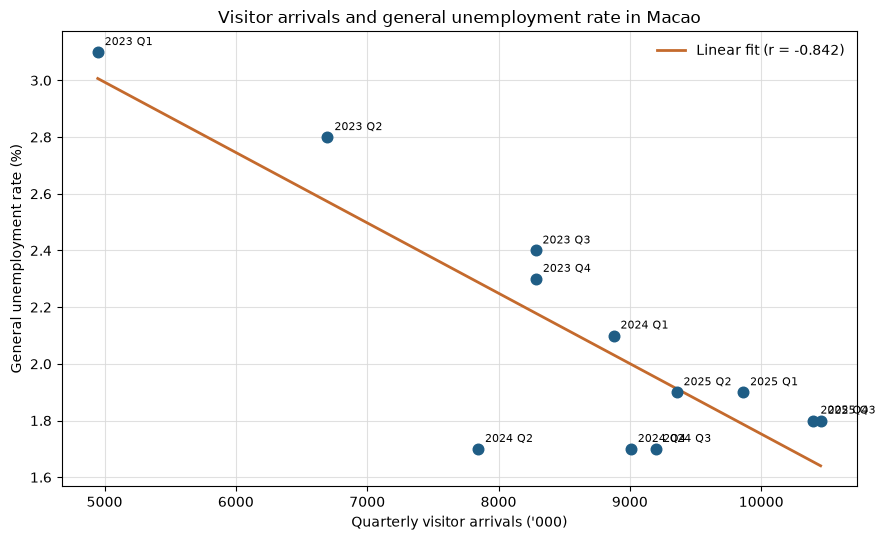

WindowsPath('../03_Visuals/Visitor_Arrivals_vs_Unemployment.png')

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, color='#1F5D85', s=58, zorder=3)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='#C46A2D', linewidth=2, label=f'Linear fit (r = {r:.3f})')
for _, row in data.iterrows():
    ax.annotate(row['Quarter'], (row['Visitor_arrivals_thousand'], row['General_unemployment_rate_percent']), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_title('Visitor arrivals and general unemployment rate in Macao')
ax.set_xlabel("Quarterly visitor arrivals ('000)")
ax.set_ylabel('General unemployment rate (%)')
ax.grid(True, color='#D9D9D9', linewidth=0.8, alpha=0.8)
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
visual_dir = Path('..') / '03_Visuals'
visual_dir.mkdir(parents=True, exist_ok=True)
figure_path = visual_dir / 'Visitor_Arrivals_vs_Unemployment.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()
figure_path

## Interpretation

The 12 quarterly observations show a strong negative association: quarters with more visitor arrivals generally have lower general unemployment. The result should be treated as preliminary because the sample is small, both series share a broad recovery trend, visitor arrivals are seasonal, and other factors such as policy changes and labour supply may affect unemployment.